# test_JOG analysis

This notebook loads `output.txt`, prints the input files used for the run, and plots the requested quantities versus time.

In [22]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)

CANDIDATES = [
    Path.cwd(),
    Path.cwd() / 'sciantix-official' / 'regression' / 'test_JOG',
    Path('sciantix-official/regression/test_JOG'),
    Path('/home/ecappellari/transparant/sciantix-official/regression/test_JOG'),
]

DATA_DIR = next((path for path in CANDIDATES if (path / 'output.txt').exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Could not locate test_JOG data directory containing output.txt')

print(f'Using data directory: {DATA_DIR.resolve()}')

def load_output_table(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep='\t')
    empty_columns = [col for col in df.columns if not str(col).strip() or str(col).startswith('Unnamed:')]
    if empty_columns:
        df = df.drop(columns=empty_columns)
    return df

def read_text(path: Path) -> str:
    return path.read_text(encoding='utf-8').strip()

def display_file(title: str, path: Path) -> None:
    display(Markdown(f'## {title}\n`{path.name}`'))
    if path.suffix == '.json':
        payload = json.loads(path.read_text(encoding='utf-8'))
        print(json.dumps(payload, indent=2))
    else:
        print(read_text(path))
    print()

Using data directory: /home/ecappellari/transparant/sciantix-official/regression/test_JOG


In [23]:
output = load_output_table(DATA_DIR / 'output.txt')
output.head()

,Time (h),Temperature (K),Fission rate (fiss / m3 s),Hydrostatic stress (MPa),Steam pressure (atm),System pressure (Pa),Grain radius (m),Xe produced (at/m3),Xe in grain (at/m3),Xe in intragranular solution (at/m3),Xe in intragranular bubbles (at/m3),Xe at grain boundary (at/m3),Xe released (at/m3),Kr produced (at/m3),Kr in grain (at/m3),Kr in intragranular solution (at/m3),Kr in intragranular bubbles (at/m3),Kr at grain boundary (at/m3),Kr released (at/m3),Fission gas release (/),Cs produced (at/m3),Cs in grain (at/m3),Cs in intragranular solution (at/m3),Cs in intragranular bubbles (at/m3),Cs at grain boundary (at/m3),Cs released (at/m3),Cs reacted - GB (at/m3),I produced (at/m3),I in grain (at/m3),I in intragranular solution (at/m3),I in intragranular bubbles (at/m3),I at grain boundary (at/m3),I released (at/m3),I reacted - GB (at/m3),Te produced (at/m3),Te in grain (at/m3),Te in intragranular solution (at/m3),Te in intragranular bubbles (at/m3),Te at grain boundary (at/m3),Te released (at/m3),Te reacted - GB (at/m3),Mo produced (at/m3),Mo in grain (at/m3),Mo in intragranular solution (at/m3),Mo in intragranular bubbles (at/m3),Mo at grain boundary (at/m3),Mo released (at/m3),Mo reacted - GB (at/m3),Intragranular bubble concentration (bub/m3),Intragranular bubble radius (m),Intragranular gas bubble swelling (/),Intergranular bubble concentration (bub/m2),Intergranular atoms per bubble (at/bub),Intergranular vacancies per bubble (vac/bub),Intergranular bubble radius (m),Intergranular bubble area (m2),Intergranular bubble volume (m3),Intergranular fractional coverage (/),Intergranular saturation fractional coverage (/),Intergranular gas swelling (/),Intergranular fractional intactness (/),Burnup (MWd/kgUO2),FIMA (%),Fuel density (kg/m3),U235 (at/m3),U238 (at/m3),Gap oxygen partial pressure (MPa),Stoichiometry deviation (/),Equilibrium stoichiometry deviation (/),Fuel oxygen partial pressure (MPa),Fuel oxygen potential (KJ/mol),Uranium content (mol/m3),Oxygen content (mol/m3),JOG thickness (um)
0,0,1000,9.000000e+18,-1,0,1000000,0.000004,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0,0.000000e+00,0.0,0.000000e+00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2.000000e+13,0.0,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.5,0.000000,1,0.000000,0.000000,10641,7.209709e+26,2.301694e+28,0,0.000000,0,0.000000e+00,0.0000,39411.11,78822.22,0.0
1,1000,1000,9.000000e+18,-1,0,1000000,0.000004,7.776000e+24,6.779688e+24,6.779688e+24,0.000000e+00,9.963119e+23,0.0,9.720000e+23,8.474610e+23,8.474610e+23,0.000000e+00,1.245390e+23,0.0,0.0,6.771600e+24,5.903978e+24,5.903978e+24,0,8.676216e+23,0.0,0.000000e+00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6.674400e+24,5.819232e+24,5.819232e+24,0,8.551677e+23,0.0,0.000000e+00,1.325206e+24,0.000000e+00,0.000000,1.996996e+13,189861.2,15677.07,2.981108e-08,1.638375e-15,1.871143e-23,0.032718,0.5,0.000280,1,1.099521,0.136490,10641,7.209709e+26,2.301694e+28,0,0.000177,0,1.611224e-17,-302.4407,39407.62,78822.22,0.0
2,2000,1000,9.000000e+18,-1,0,1000000,0.000004,1.555200e+25,1.315604e+25,1.205500e+25,1.101042e+24,2.395962e+24,0.0,1.944000e+24,1.644505e+24,1.506875e+24,1.376302e+23,2.994952e+23,0.0,0.0,1.354320e+25,1.139592e+25,1.139592e+25,0,0.000000e+00,0.0,2.147275e+24,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.334880e+25,1.123235e+25,1.123235e+25,0,0.000000e+00,0.0,2.116453e+24,1.326290e+24,0.000000e+00,0.000000,1.995201e+13,180129.4,24600.33,2.824035e-08,1.470273e-15,1.590686e-23,0.029335,0.5,0.000238,1,2.199041,0.272981,10641,7.209709e+26,2.301694e+28,0,0.000355,0,6.448395e-17,-290.9106,39404.12,78822.22,0.0
3,3000,1000,9.000000e+18,-1,0,1000000,0.000004,2.332800e+25,1.919591e+25,1.758818e+25,1.607729e+24,4.132093e+24,0.0,2.916000e+24,2.399488e+24,2.198522e+24,2.009661e+23,5.165116e+23,0.0,0.0,2.031480

In [24]:
files_to_show = [
    ('Input settings', DATA_DIR / 'input_settings.txt'),
    ('Input initial conditions', DATA_DIR / 'input_initial_conditions.txt'),
    ('Input history', DATA_DIR / 'input_history.txt'),
    ('Input scaling factors', DATA_DIR / 'input_scaling_factors.txt'),
    ('Thermochemistry input', DATA_DIR / 'input_thermochemistry.json'),
    ('Overview', DATA_DIR / 'overview.txt'),
]

for title, path in files_to_show:
    display_file(title, path)

## Input settings
`input_settings.txt`

1    #    iGrainGrowth (0= no grain growth, 1= Ainscough et al. (1973), 2= Van Uffelen et al. (2013))
1    #    iFissionGasDiffusivity (0= constant value, 1= Turnbull et al. (1988))
1    #    iDiffusionSolver (1= SDA with quasi-stationary hypothesis, 2= SDA without quasi-stationary hypothesis)
1    #    iIntraGranularBubbleBehavior (1= Pizzocri et al. (2018))
1    #    iResolutionRate (0= constant value, 1= Turnbull (1971), 2= Losonen (2000), 3= thermal resolution, Cognini et al. (2021))
1    #    iTrappingRate (0= constant value, 1= Ham (1958))
1    #    iNucleationRate (0= constant value, 1= Olander, Wongsawaeng (2006))
1    #    iOutput (1= default output files)
2    #    iGrainBoundaryVacancyDiffusivity (0= constant value, 1= Reynolds and Burton (1979), 2= White (2004))
1    #    iGrainBoundaryBehaviour (0= no grain boundary bubbles, 1= Pastore et al (2013))
1    #    iGrainBoundaryMicroCracking (0= no model considered, 1= Barani et al. (2017))
0    #    iFuelMatrix (0= UO2, 1= UO2

## Input initial conditions
`input_initial_conditions.txt`

4.0e-06
#	initial grain radius (m)
0.0	0.0	0.0	0.0	0.0	0.0
#	initial Xe (at/m3) produced, intragranular, intragranular in solution, intragranular in bubbles, grain boundary, released
0.0	0.0	0.0	0.0	0.0	0.0
#	initial Kr (at/m3) produced, intragranular, intragranular in solution, intragranular in bubbles, grain boundary, released
0.0	0.0	0.0	0.0	0.0	0.0
#	initial He (at/m3) produced, intragranular, intragranular in solution, intragranular in bubbles, grain boundary, released
0.0 0.0
# initial intragranular bubble concentration (at/m3), radius (m)
0.0
#	initial fuel burn-up (MWd/kgUO2)
0.0
#	initial fuel effective burn-up (MWd/kgUO2)
0.0
#	initial irradiation time (h)
10641.0
#	initial fuel density (kg/m3)
0.0	3.0	0.0	0.0	97.0
#	initial U234 U235 U236 U237 U238 (% of heavy atoms) content
0.0	0.0	0.0	0.0	0.0	0.0 0.0
#	initial Xe133 (at/m3) produced, intragranular, intragranular in solution, intragranular in bubbles, decayed, grain boundary, released
0.0	0.0	0.0	0.0	0.0	0.0 0.0
#	initial K

## Input history
`input_history.txt`

...

1.0
# scaling factor - resolution rate
1.0
# scaling factor - trapping rate
1.0
# scaling factor - nucleation rate
1.0
# scaling factor - diffusivity
1.0
# scaling factor - diffusivity2
1.0
# scaling factor - temperature
1.0
# scaling factor - fission rate
1.0
# scaling factor - cent parameter
1.0
# scaling factor - helium production rate
1.0
# scaling factor - dummy



## Thermochemistry input
`input_thermochemistry.json`

{
  "Settings": {
    "KC": false,
    "KC time": 53400.099,
    "Langmuir": false,
    "Langmuir coefficient": 1e-07,
    "fission_products": {
      "elements": {
        "Cs": {
          "atomicnumber": 55
        },
        "Mo": {
          "atomicnumber": 42
        },
        "O": {
          "atomicnumber": 16
        }
      },
      "module": "OPENCALPHAD",
      "database": "CsMoO_TAFID_2021_Anna",
      "location": {
        "at grain boundary": {}
      },
      "gap settings": false,
      "gap temperature": 600,
      "gap pressure": 1000000
    },
    "matrix": {
      "elements": {
        "U": {
          "atomicnumber": 92
        },
        "O": {
          "atomicnumber": 8
        }
      },
      "module": "NO",
      "database": "OU",
      "location": {
        "matrix": {}
      }
    },
    "_comments": {
      "available_modules": "OPENCALPHAD, THERMOCHIMICA",
      "available_databases_OPENCALPHAD": "CsITe_fake, OU",
      "available_databases_THERMOCHIMIC

## Overview
`overview.txt`

Model	Burnup	: The local burnup is calculated from the fission rate density.
Model	Effective burnup	: G. Khvostov et al., WRFPM-2005, Kyoto, Japan, 2005.
Model	UO2 thermochemistry	 : Blackburn (1973) J. Nucl. Mater., 46, 244-252.
Model	Stoichiometry deviation	 : H. Kleykamp, The chemical state of LWR high-power rods under irradiation, Journal of Nuclear Materials (1979)
Model	Grain growth	 : Ainscough et al., JNM, 49 (1973) 117-128.
Model	Gas production - Xe in UO2	 
Model	Gas production - Kr in UO2	 
Model	Gas production - He in UO2	 
Model	Gas production - Xe133 in UO2	 
Model	Gas production - Kr85m in UO2	 
Model	Gas production - Cs in UO2	 
Model	Gas production - I in UO2	 
Model	Gas production - Te in UO2	 
Model	Gas production - Mo in UO2	 
Model	Intragranular bubble behavior	: Pizzocri et al., JNM, 502 (2018) 323-330.
Model	Gas diffusion - Xe in UO2	
Model	Gas diffusion - Kr in UO2	
Model	Gas diffusion - He in UO2	
Model	Gas diffusion - Xe133 in UO2	
Model	Gas diffusion - Kr85m 

In [25]:
history_columns = [
    'Time (s)',
    'Temperature (K)',
    'Fission rate (fiss / m3 s)',
    'Hydrostatic stress (MPa)',
    'Pressure (Pa)',
]
history = pd.read_csv(
    DATA_DIR / 'input_history.txt',
    sep=r'\s+',
    comment='#',
    header=None,
    names=history_columns,
)
display(Markdown('## Parsed input history'))
history

## Parsed input history

,Time (s),Temperature (K),Fission rate (fiss / m3 s),Hydrostatic stress (MPa),Pressure (Pa)
0,0,1000,9.000000e+18,-1,1000000.0
1,100000,1000,9.000000e+18,-1,1000000.0


In [ ]:
time = output['Time (h)']

pressure_mpa = pd.DataFrame({
    'Steam pressure (MPa)': output['Steam pressure (atm)'] * 0.101325,
    'THERMOCHIMICA pressure (MPa)': output['System pressure (Pa)'] / 1.0e6,
    'Gap oxygen partial pressure (MPa)': output['Gap oxygen partial pressure (MPa)'],
    'Fuel oxygen partial pressure (MPa)': output['Fuel oxygen partial pressure (MPa)'],
})

fig, axes = plt.subplots(4, 2, figsize=(14, 15), sharex=True)
axes = axes.ravel()

axes[0].plot(time, output['Temperature (K)'], color='tab:red')
axes[0].set_title('Temperature')
axes[0].set_ylabel('K')

for column in pressure_mpa.columns:
    axes[1].plot(time, pressure_mpa[column], label=column)
axes[1].set_title('Pressure-like quantities')
axes[1].set_ylabel('MPa')
axes[1].legend(fontsize=8)

axes[2].plot(time, output['Stoichiometry deviation (/)'], label='Stoichiometry deviation')
axes[2].plot(time, output['Equilibrium stoichiometry deviation (/)'], label='Equilibrium stoichiometry deviation')
axes[2].set_title('Stoichiometry deviation')
axes[2].set_ylabel('dimensionless')
axes[2].legend(fontsize=8)

axes[3].plot(time, output['Burnup (MWd/kgUO2)'], color='tab:green')
axes[3].set_title('Burnup')
axes[3].set_ylabel('MWd/kgUO2')

axes[4].plot(time, output['FIMA (%)'], color='tab:orange')
axes[4].set_title('FIMA')
axes[4].set_ylabel('%')

axes[5].plot(time, output['Grain radius (m)'] * 1.0e6, color='tab:purple')
axes[5].set_title('Grain radius')
axes[5].set_ylabel('um')

axes[6].plot(time, output['Fission gas release (/)'], color='tab:brown')
axes[6].set_title('Fission gas release')
axes[6].set_ylabel('dimensionless')

axes[7].axis('off')

for ax in axes[:-1]:
    ax.set_xlabel('Time (h)')

fig.suptitle('Key state variables vs time', fontsize=16)
fig.tight_layout()
plt.show()

KeyError: 'THERMOCHIMICA pressure (Pa)'

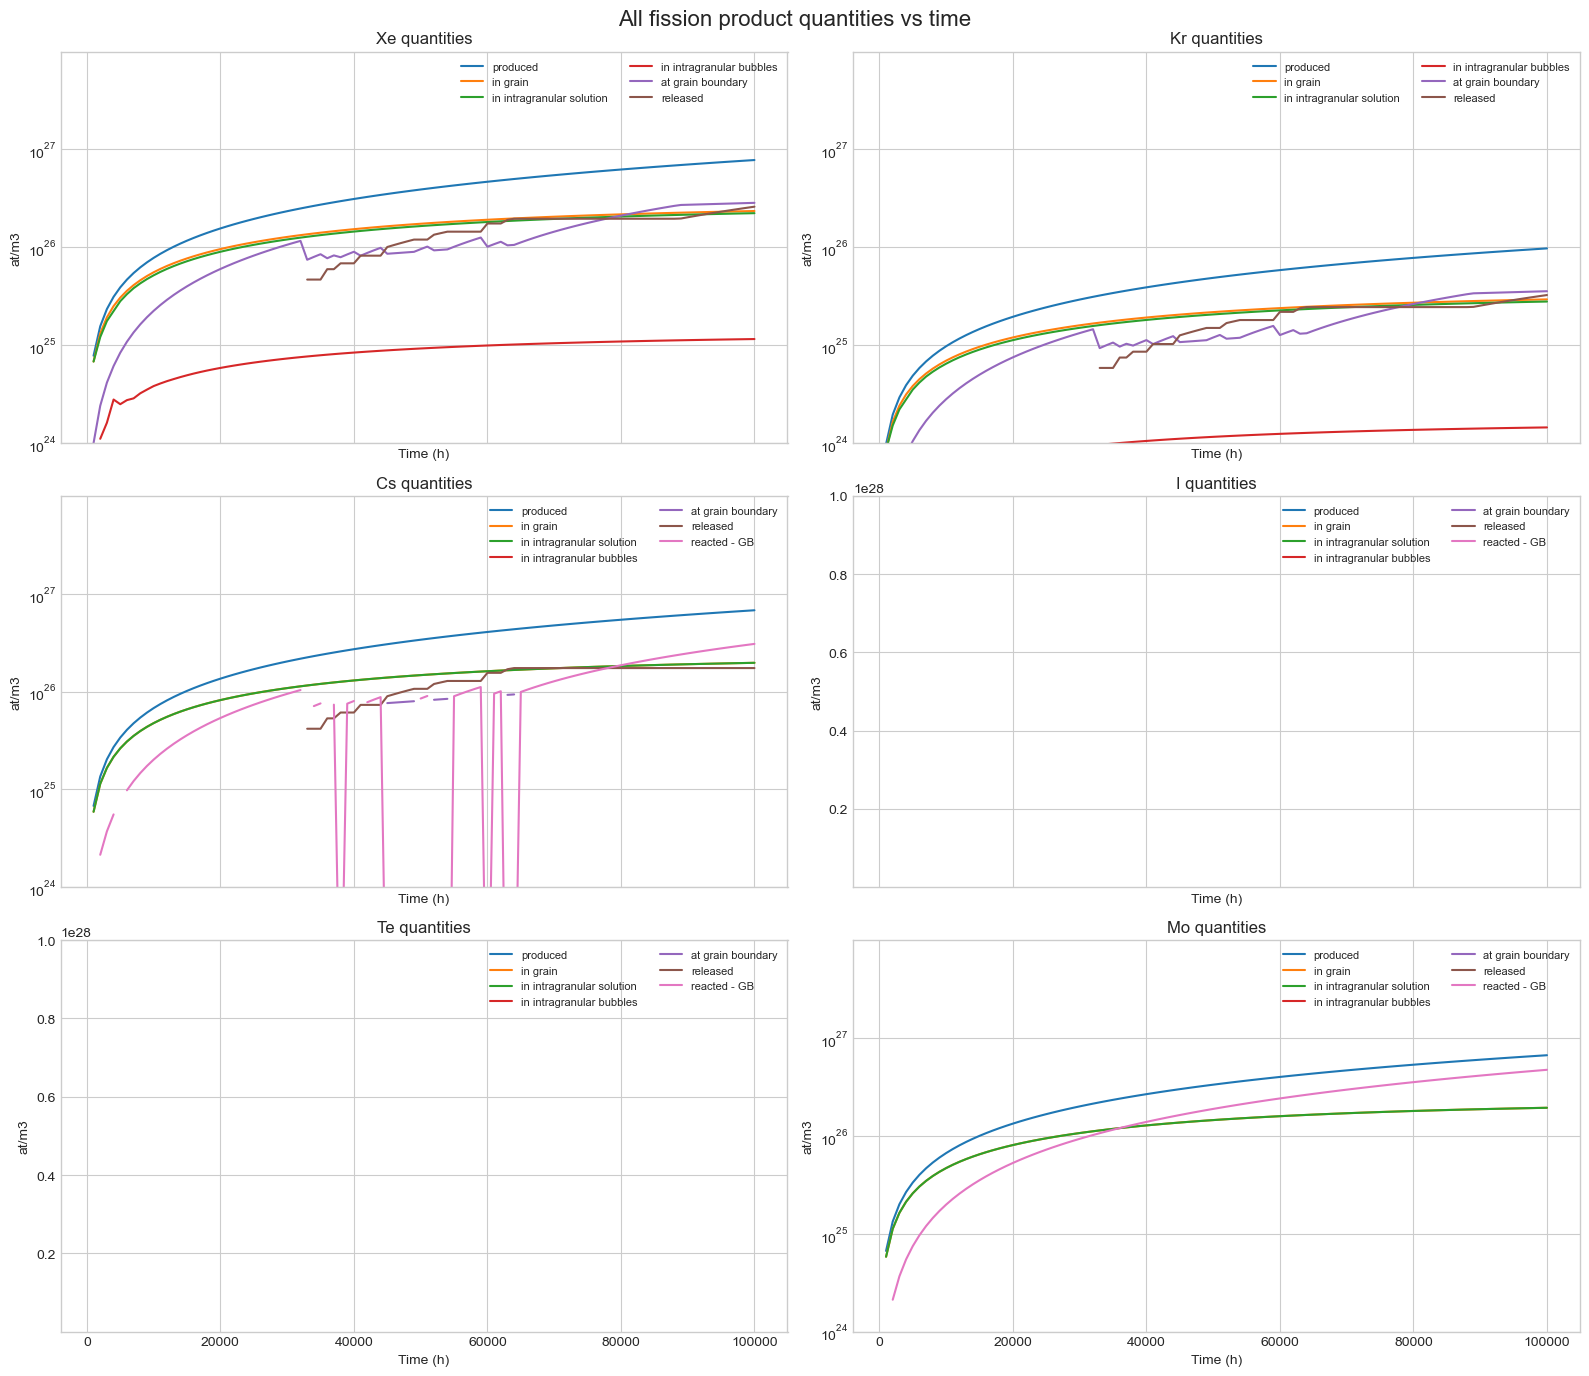

In [ ]:
fission_products = ['Xe', 'Kr', 'Cs', 'I', 'Te', 'Mo']
unit_suffixes = [' (at/m3)', ' (/)']

def cleaned_label(column: str, species: str) -> str:
    label = column.replace(f'{species} ', '', 1)
    for suffix in unit_suffixes:
        label = label.replace(suffix, '')
    return label

fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True)
axes = axes.ravel()

for ax, species in zip(axes, fission_products):
    species_columns = [
        col for col in output.columns
        if col.startswith(f'{species} ') and '(at/m3)' in col
    ]
    for column in species_columns:
        series = output[column].where(output[column] > 0)
        ax.plot(time, series, label=cleaned_label(column, species))
    ax.set_title(f'{species} quantities')
    ax.set_ylabel('at/m3')
    ax.set_xlabel('Time (h)')
    if any(output[column].gt(0).any() for column in species_columns):
        positives = [output[column][output[column] > 0].min() for column in species_columns if output[column].gt(0).any()]
        linthresh = min(positives) if positives else 1.0
        ax.set_yscale('symlog', linthresh=max(linthresh, 1.0))
    ax.set_ylim([1e24, 1e28])
    ax.legend(fontsize=8, ncol=2)

fig.suptitle('All fission product quantities vs time', fontsize=16)
fig.tight_layout()
plt.show()

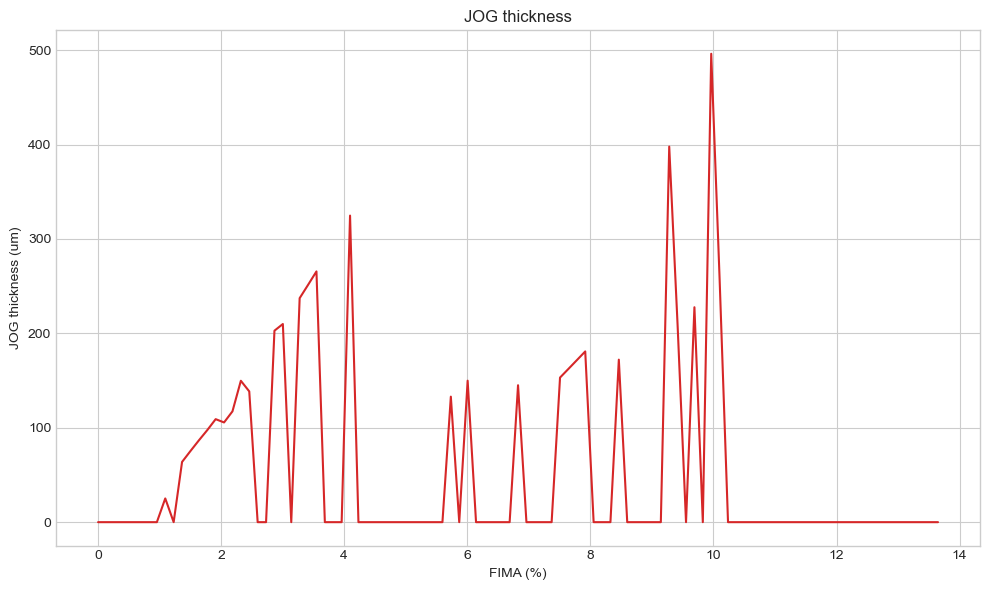

In [ ]:
time = output['FIMA (%)']

fig, axes = plt.subplots(1, 1, figsize=(10, 6))

axes.plot(time, output['JOG thickness (um)'], color='tab:red')
axes.set_title('JOG thickness')
axes.set_ylabel('JOG thickness (um)')
axes.set_xlabel('FIMA (%)')
fig.tight_layout()
plt.show()